## Import Library

In [ ]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

from sklearn import preprocessing
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import recall_score, confusion_matrix, precision_score, f1_score, accuracy_score, classification_report
from sklearn import metrics
from sklearn.model_selection import cross_val_score

from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_curve

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

## Load dataset

In [ ]:
df = pd.read_csv('1702184567307-WA_FnUseC_TelcoCustomerChurn.csv')
df.head(5)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [ ]:
# dealing with nan
print(df.isnull().sum())
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

print(df.isnull().sum())
median_total_charges = df['TotalCharges'].median()
df["TotalCharges"] = df['TotalCharges'].fillna(median_total_charges)

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64
customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df = df.drop('customerID', axis=1)

categorical_cols = ['gender', 'SeniorCitizen', 'Partner', 'Dependents',
                    'PhoneService', 'MultipleLines', 'InternetService',
                    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
                    'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
                    'PaperlessBilling', 'PaymentMethod', 'Churn']
continuous_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

In [ ]:
df[continuous_cols].describe()

,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000
mean,32.371149,64.761692,2281.916928
std,24.559481,30.090047,2265.270398
min,0.000000,18.250000,18.800000
25%,9.000000,35.500000,402.225000
50%,29.000000,70.350000,1397.475000
75%,55.000000,89.850000,3786.600000
max,72.000000,118.750000,8684.800000


In [ ]:
# encoding
le = preprocessing.LabelEncoder()
for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

In [ ]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,1,0,1,0,1,0,0,2,0,0,0,0,0,1,2,29.85,29.85,0
1,1,0,0,0,34,1,0,0,2,0,2,0,0,0,1,0,3,56.95,1889.50,0
2,1,0,0,0,2,1,0,0,2,2,0,0,0,0,0,1,3,53.85,108.15,1
3,1,0,0,0,45,0,1,0,2,0,2,2,0,0,1,0,0,42.30,1840.75,0
4,0,0,0,0,2,1,0,1,0,0,0,0,0,0,0,1,2,70.70,151.65,1


## Split Dataset

In [ ]:
# split dataset
X = df.drop('Churn', axis=1)
y = df['Churn']

## Train

## EDA

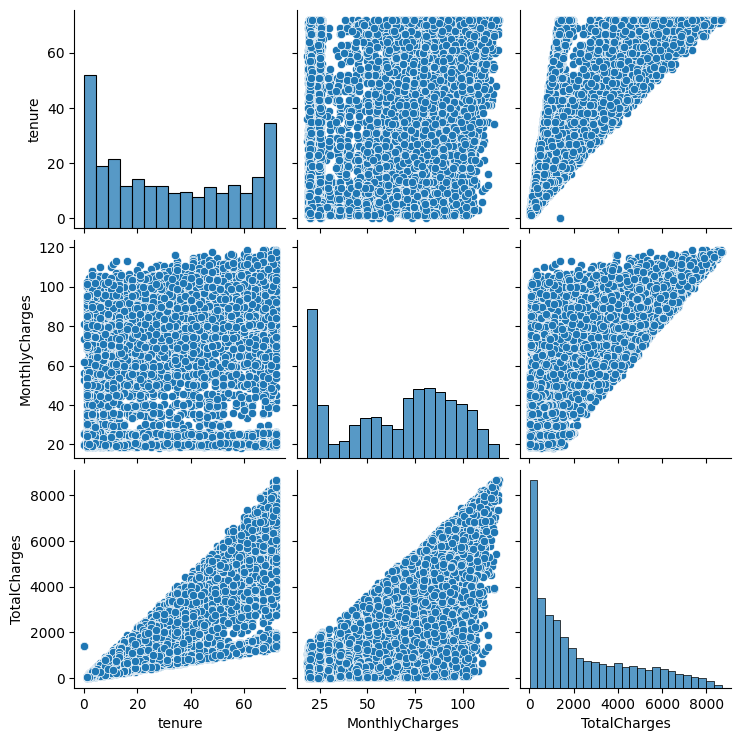

In [ ]:
# Visualisasikan distribusi data untuk memahami pola dan karakteristiknya
sns.pairplot(df[continuous_cols])
plt.show()


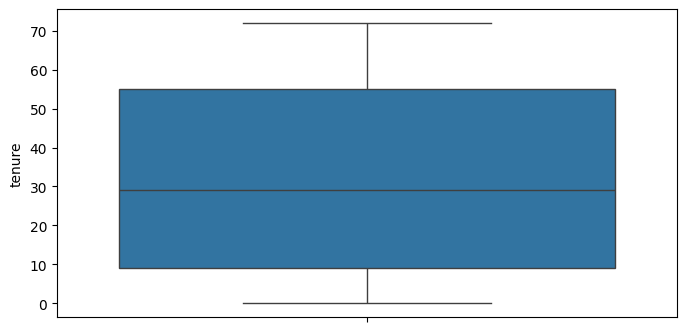

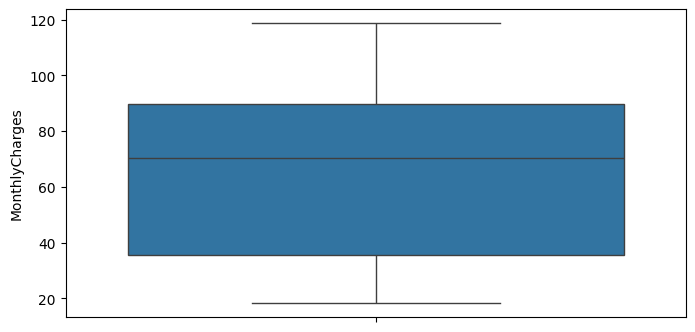

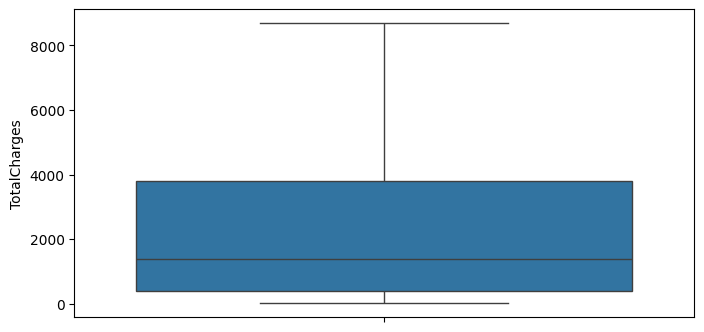

In [ ]:
# boxplot
for col in continuous_cols:
    plt.figure(figsize=(8, 4))
    sns.boxplot(df[col])

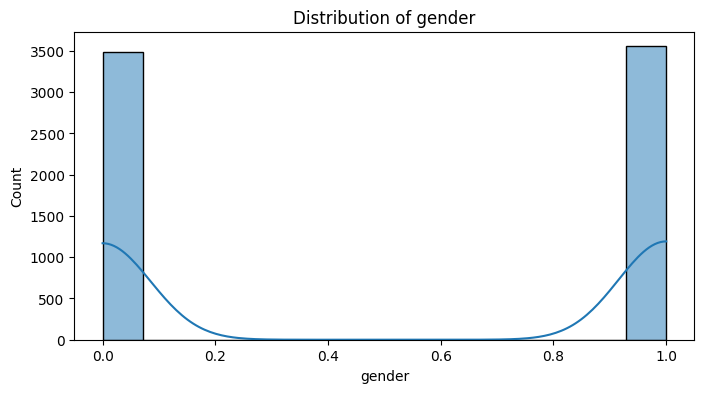

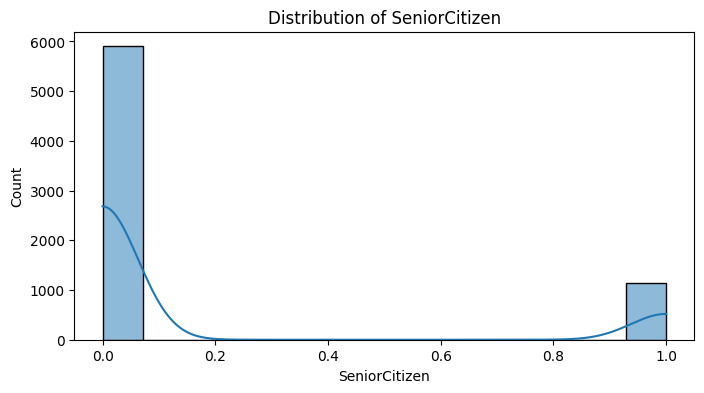

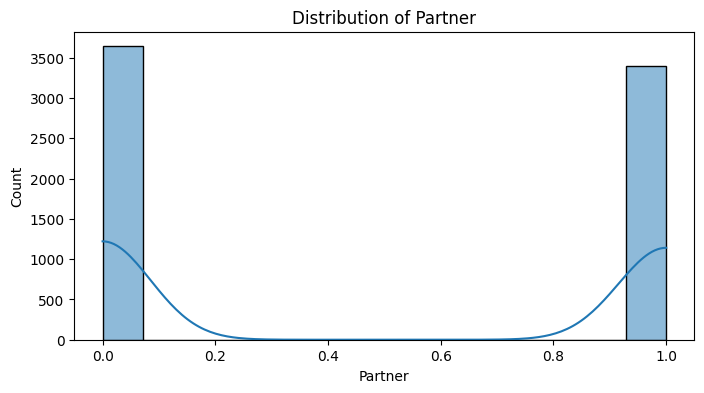

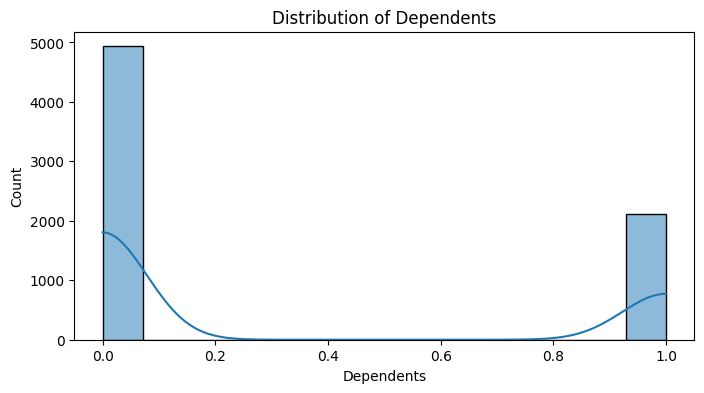

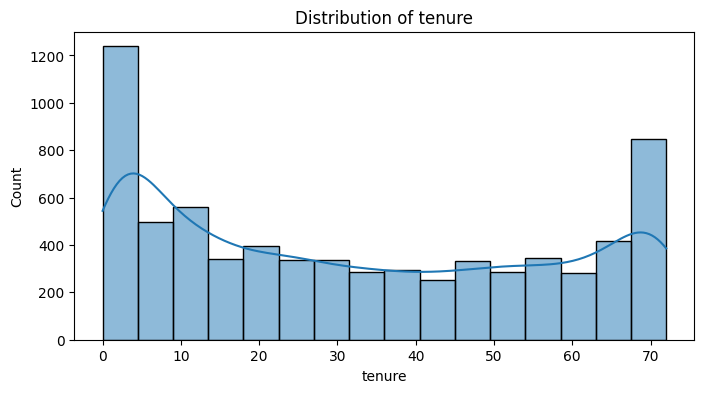

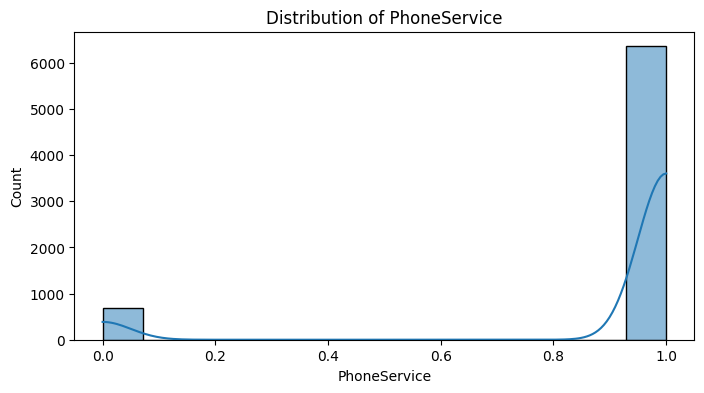

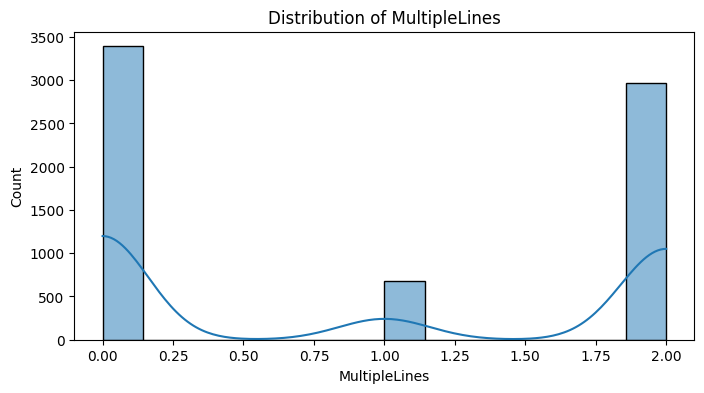

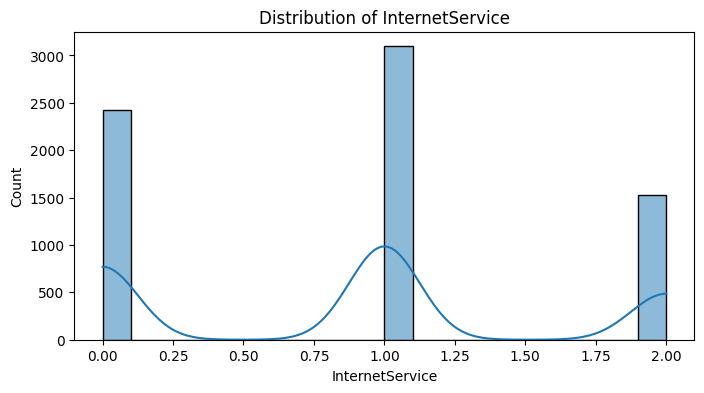

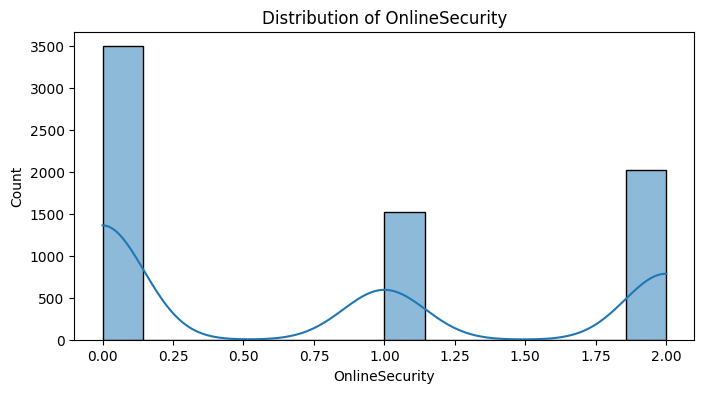

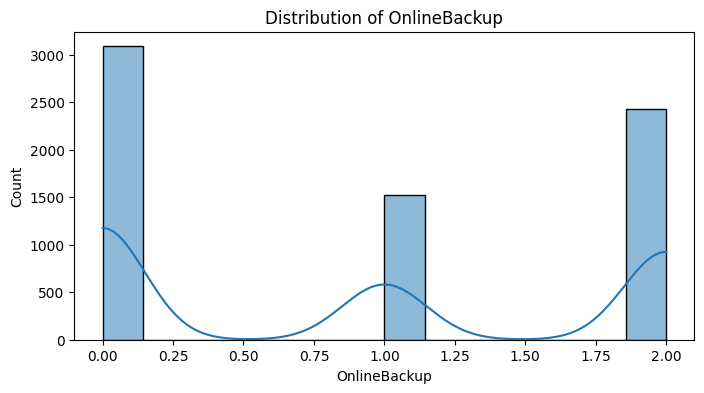

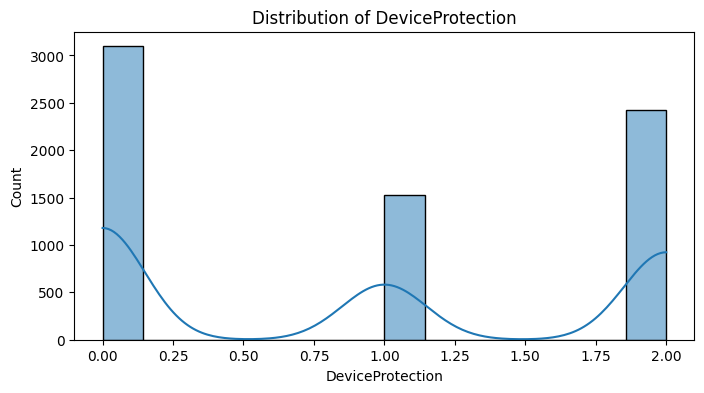

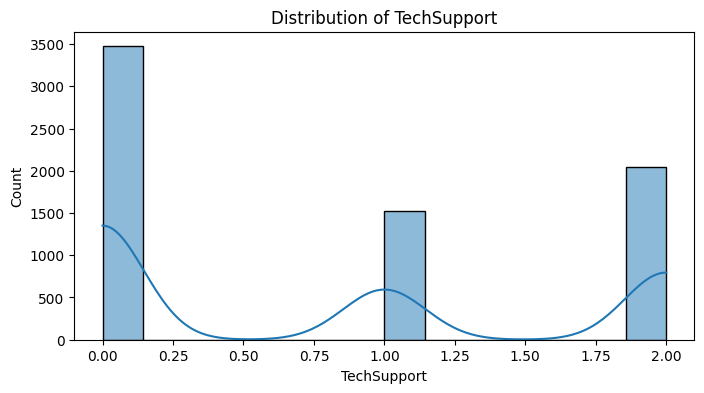

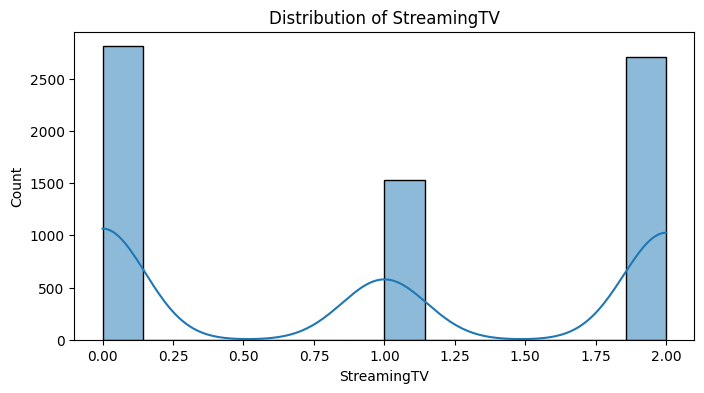

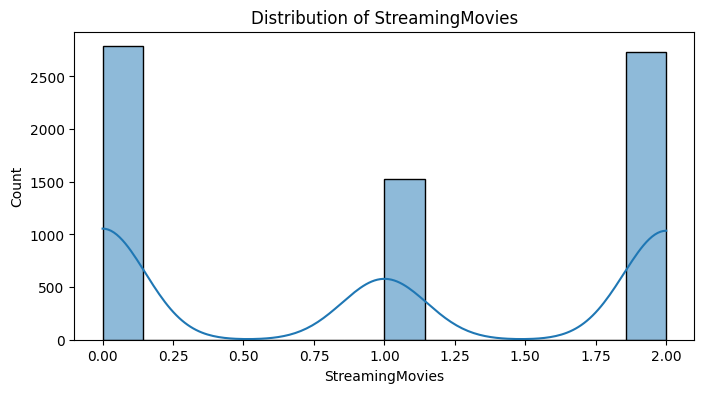

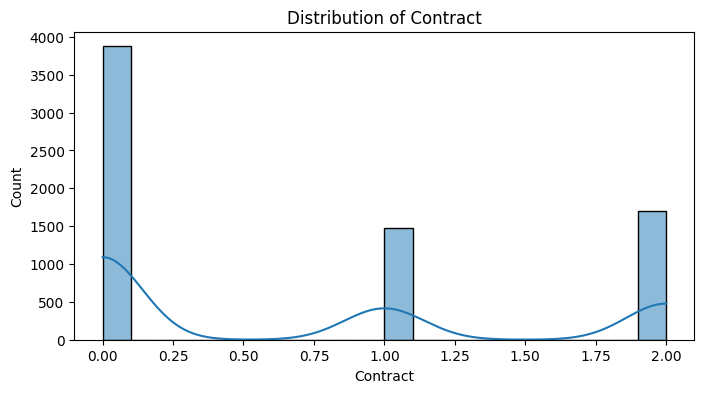

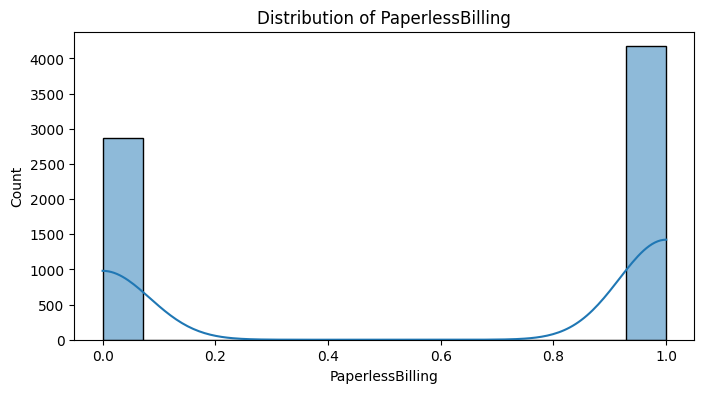

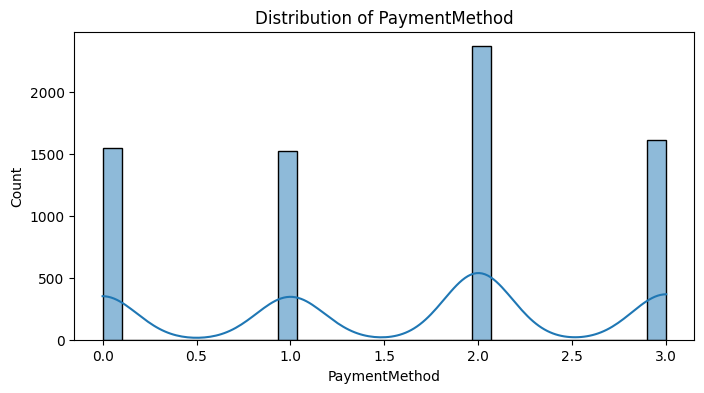

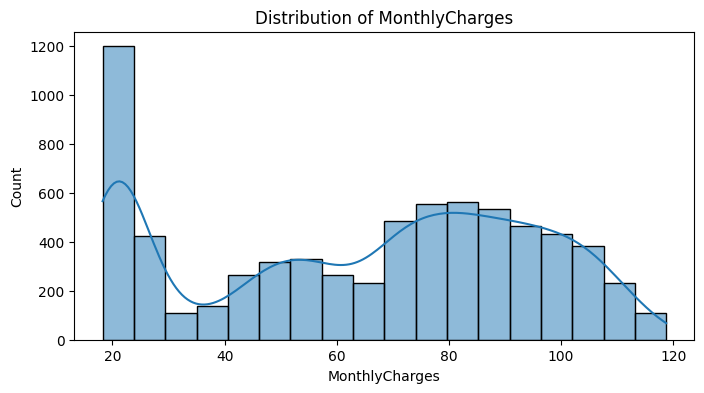

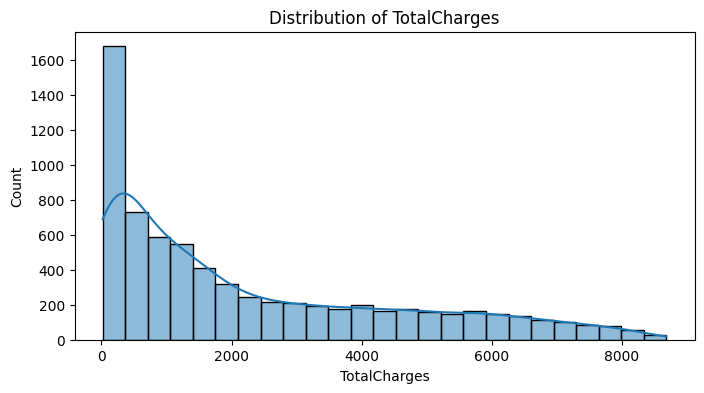

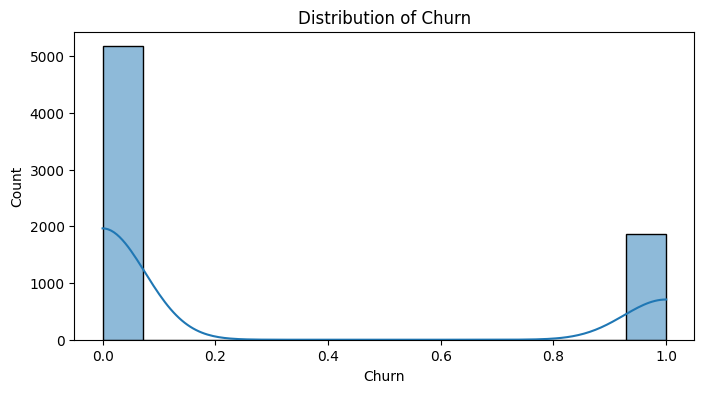

In [ ]:
# Lakukan analisis terhadap distribusi data numerik dan kategorikal
for col in df.columns:
    plt.figure(figsize=(8, 4))
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.show()

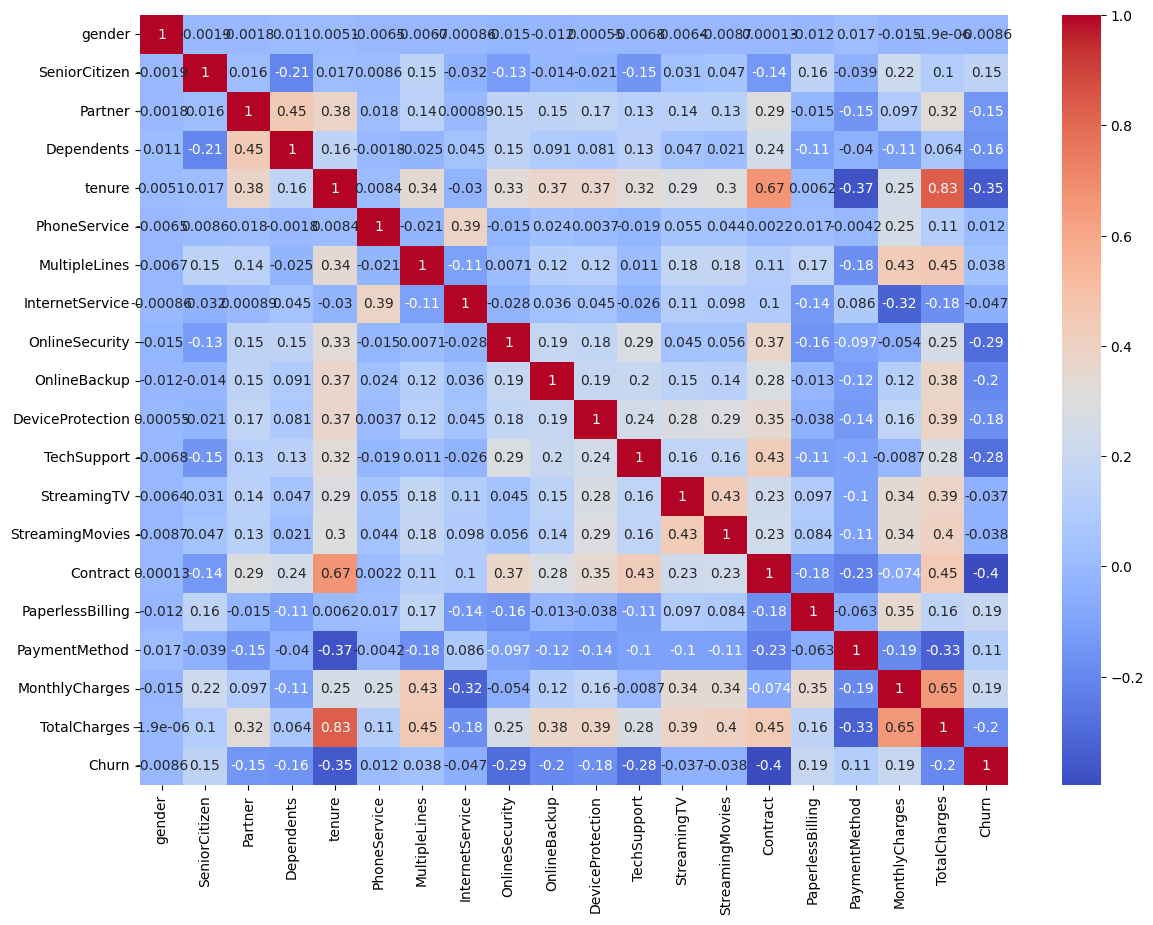

In [ ]:
# Identifikasi korelasi antar fitur dan fitur dengan target.
plt.figure(figsize=(14,10))
correlation_matrix = df.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.show()

In [ ]:
df.corr()['Churn'].sort_values(ascending = False)

,Churn
Churn,1.000000
MonthlyCharges,0.193356
PaperlessBilling,0.191825
SeniorCitizen,0.150889
PaymentMethod,0.107062
MultipleLines,0.038037
PhoneService,0.011942
gender,-0.008612
StreamingTV,-0.036581
StreamingMovies,-0.038492


### Data Preprocessing

In [ ]:
# create train, val, test dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.25, random_state=42)

In [ ]:
# standart scaller for numerical columns
scaler = StandardScaler()
X_train[continuous_cols] = scaler.fit_transform(X_train[continuous_cols])
X_val[continuous_cols] = scaler.transform(X_val[continuous_cols])
X_test[continuous_cols] = scaler.transform(X_test[continuous_cols])


### Modeling

In [ ]:
from sklearn.tree import DecisionTreeClassifier

best_score = 0
best_depth = None

for depth in range(2, 21):
    model = DecisionTreeClassifier(max_depth=depth, random_state=42)
    # Perform 5-fold cross-validation
    scores = cross_val_score(model, X_train, y_train, cv=5, scoring='accuracy')
    mean_score = scores.mean()

    if mean_score > best_score:
        best_score = mean_score
        best_depth = depth

print(f"Best depth: {best_depth}, Validation Accuracy: {best_score:.4f}")

Best depth: 5, Validation Accuracy: 0.7844


In [ ]:
final_model = DecisionTreeClassifier(max_depth=best_depth, random_state=42)
final_model.fit(X_train, y_train)
test_pred = final_model.predict(X_test)

print(classification_report(y_test, test_pred))

              precision    recall  f1-score   support

           0       0.83      0.90      0.87      1036
           1       0.64      0.51      0.57       373

    accuracy                           0.79      1409
   macro avg       0.74      0.70      0.72      1409
weighted avg       0.78      0.79      0.79      1409



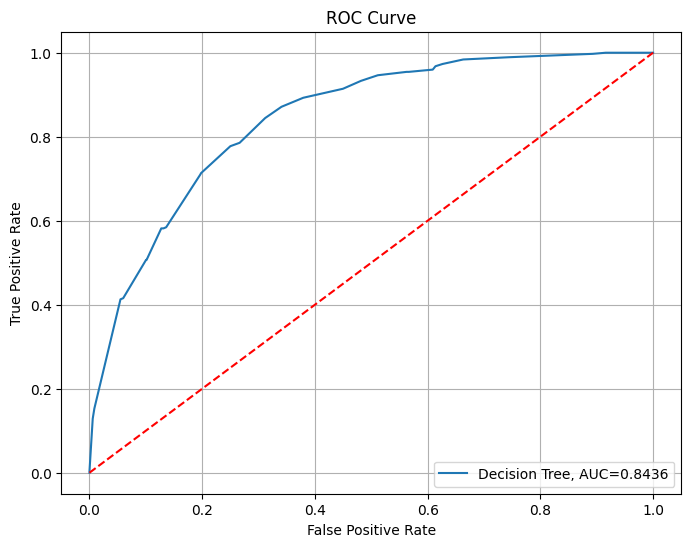

In [ ]:
# ROC-AUC curve for Decision Tree
y_test_pred_proba = final_model.predict_proba(X_test)[::,1]
fpr, tpr, _ = roc_curve(y_test, y_test_pred_proba)
auc = roc_auc_score(y_test, y_test_pred_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label="Decision Tree, AUC=" + str(round(auc, 4)))
plt.plot([0, 1], [0, 1], 'r--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc=4)
plt.grid(True)
plt.show()

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Use k-fold cross-validation to find the best hyperparameters
best_acc = 0
best_model = None

for depth in [5, 10, 15, None]:
    for trees in [100, 200, 300]:
        rf = RandomForestClassifier(
            n_estimators=trees,
            max_depth=depth,
            random_state=42
        )
        # Perform 5-fold cross-validation
        scores = cross_val_score(rf, X_train, y_train, cv=5, scoring='accuracy')
        mean_acc = scores.mean()

        if mean_acc > best_acc:
            best_acc = mean_acc
            best_model = rf

print(f"Cross-validation Accuracy: {best_acc:.4f}")

Cross-validation Accuracy: 0.8012


In [ ]:
# Train the best model on the entire training set
best_model.fit(X_train, y_train)

# Predict on test set
test_pred = best_model.predict(X_test)

# Evaluate on test set
print(classification_report(y_test, test_pred))

              precision    recall  f1-score   support

           0       0.84      0.91      0.87      1036
           1       0.67      0.51      0.58       373

    accuracy                           0.80      1409
   macro avg       0.75      0.71      0.73      1409
weighted avg       0.79      0.80      0.79      1409



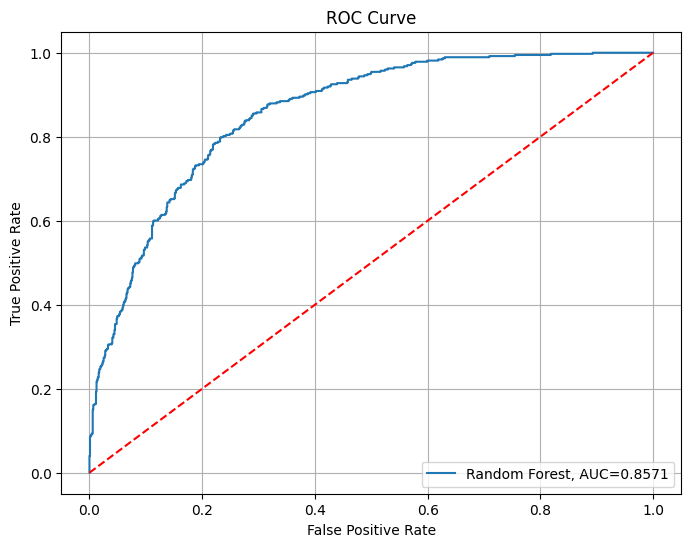

In [ ]:
# ROC-AUC curve for Random Forest
y_test_pred_proba_rf = best_model.predict_proba(X_test)[::,1]
fpr_rf, tpr_rf, _rf = roc_curve(y_test, y_test_pred_proba_rf)
auc_rf = roc_auc_score(y_test, y_test_pred_proba_rf)

plt.figure(figsize=(8, 6))
plt.plot(fpr_rf, tpr_rf, label="Random Forest, AUC=" + str(round(auc_rf, 4)))
plt.plot([0, 1], [0, 1], 'r--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc=4)
plt.grid(True)
plt.show()

In [ ]:
from sklearn.linear_model import LogisticRegression

best_acc = 0
best_c = None

for c in [0.01, 0.1, 1, 10]:
    model = LogisticRegression(C=c, solver='liblinear', random_state=42)
    # Perform 5-fold cross-validation
    scores = cross_val_score(model, X_train, y_train, cv=5, scoring='accuracy')
    mean_acc = scores.mean()

    if mean_acc > best_acc:
        best_acc = mean_acc
        best_c = c
print(f"Best C={best_c}, Cross-validation Accuracy={best_acc:.4f}")

Best C=1, Cross-validation Accuracy=0.7998


In [ ]:
final_model = LogisticRegression(C=best_c, solver='liblinear', random_state=42)
final_model.fit(X_train, y_train)
test_pred = final_model.predict(X_test)

print(classification_report(y_test, test_pred))

              precision    recall  f1-score   support

           0       0.86      0.90      0.88      1036
           1       0.68      0.60      0.64       373

    accuracy                           0.82      1409
   macro avg       0.77      0.75      0.76      1409
weighted avg       0.81      0.82      0.82      1409



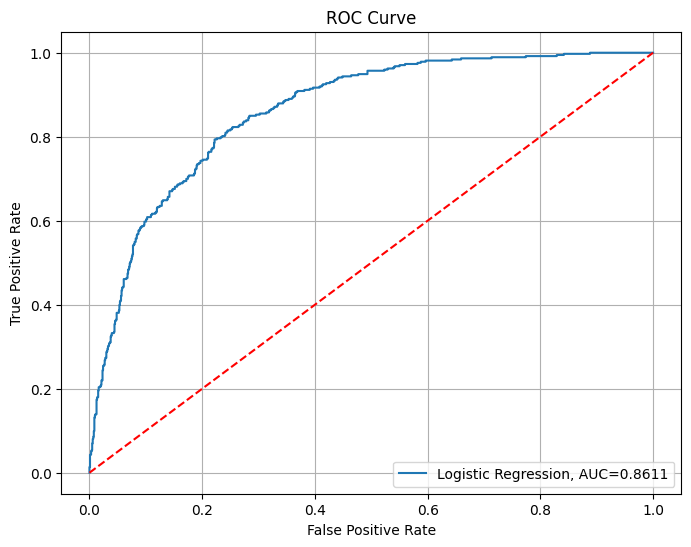

In [ ]:
# ROC-AUC curve for Logistic Regression
y_test_pred_proba_lr = final_model.predict_proba(X_test)[::,1]
fpr_lr, tpr_lr, _lr = roc_curve(y_test, y_test_pred_proba_lr)
auc_lr = roc_auc_score(y_test, y_test_pred_proba_lr)

plt.figure(figsize=(8, 6))
plt.plot(fpr_lr, tpr_lr, label="Logistic Regression, AUC=" + str(round(auc_lr, 4)))
plt.plot([0, 1], [0, 1], 'r--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc=4)
plt.grid(True)
plt.show()

In [ ]:
from sklearn.svm import SVC

best_acc = 0
best_params = {}

for c in [0.1, 1, 10]:
    for g in ['scale', 0.01, 0.001]:
        model = SVC(C=c, gamma=g, kernel='rbf', probability=True, random_state=42)
        # Perform 5-fold cross-validation
        scores = cross_val_score(model, X_train, y_train, cv=5, scoring='accuracy')
        mean_acc = scores.mean()

        if mean_acc > best_acc:
            best_acc = mean_acc
            best_params = {'C': c, 'gamma': g}

print(f"Best C={best_params['C']}, gamma={best_params['gamma']}, Cross-validation Accuracy={best_acc:.4f}")

Best C=1, gamma=0.01, Cross-validation Accuracy=0.7967


In [ ]:
final_svm = SVC(C=best_params['C'], gamma=best_params['gamma'], kernel='rbf', probability=True, random_state=42)
final_svm.fit(X_train, y_train)

# Predict on test set
y_pred = final_svm.predict(X_test)
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.84      0.92      0.88      1036
           1       0.69      0.51      0.59       373

    accuracy                           0.81      1409
   macro avg       0.77      0.72      0.73      1409
weighted avg       0.80      0.81      0.80      1409



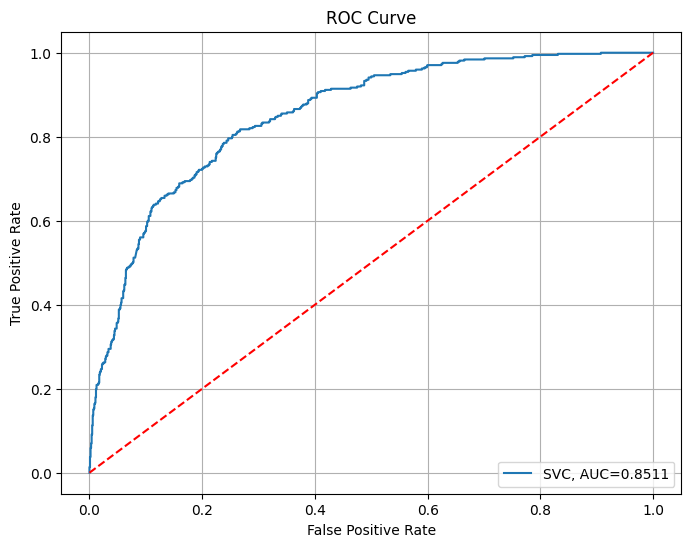

In [ ]:
# ROC-AUC curve for SVC
y_test_pred_proba_svm = final_svm.predict_proba(X_test)[::,1]
fpr_svm, tpr_svm, _svm = roc_curve(y_test, y_test_pred_proba_svm)
auc_svm = roc_auc_score(y_test, y_test_pred_proba_svm)

plt.figure(figsize=(8, 6))
plt.plot(fpr_svm, tpr_svm, label="SVC, AUC=" + str(round(auc_svm, 4)))
plt.plot([0, 1], [0, 1], 'r--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc=4)
plt.grid(True)
plt.show()

In [ ]:
from xgboost import XGBClassifier

best_acc = 0
best_params = {}

for depth in [3, 5, 7]:
    for lr in [0.01, 0.1, 0.3]:
        model = XGBClassifier(max_depth=depth, learning_rate=lr, eval_metric='logloss', use_label_encoder=False, random_state=42)
        # Perform 5-fold cross-validation
        scores = cross_val_score(model, X_train, y_train, cv=5, scoring='accuracy')
        mean_acc = scores.mean()

        if mean_acc > best_acc:
            best_acc = mean_acc
            best_params = {'max_depth': depth, 'learning_rate': lr}

print(f"Best max_depth={best_params['max_depth']}, learning_rate={best_params['learning_rate']}, Cross-validation Accuracy={best_acc:.4f}")

Best max_depth=3, learning_rate=0.1, Cross-validation Accuracy=0.8012


In [ ]:
final_model = XGBClassifier(max_depth=best_params['max_depth'], learning_rate=best_params['learning_rate'],
                            eval_metric='logloss', use_label_encoder=False, random_state=42)
final_model.fit(X_train, y_train)

# Predict on test set
y_pred = final_model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.84      0.91      0.87      1036
           1       0.68      0.52      0.59       373

    accuracy                           0.81      1409
   macro avg       0.76      0.72      0.73      1409
weighted avg       0.80      0.81      0.80      1409



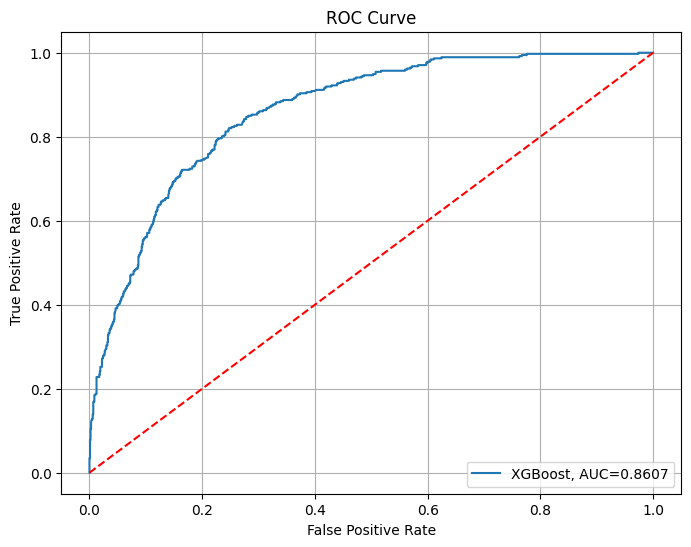

In [ ]:
# ROC-AUC curve for XGBoost
y_test_pred_proba_xgb = final_model.predict_proba(X_test)[::,1]
fpr_xgb, tpr_xgb, _xgb = roc_curve(y_test, y_test_pred_proba_xgb)
auc_xgb = roc_auc_score(y_test, y_test_pred_proba_xgb)

plt.figure(figsize=(8, 6))
plt.plot(fpr_xgb, tpr_xgb, label="XGBoost, AUC=" + str(round(auc_xgb, 4)))
plt.plot([0, 1], [0, 1], 'r--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc=4)
plt.grid(True)
plt.show()

### Evaluation

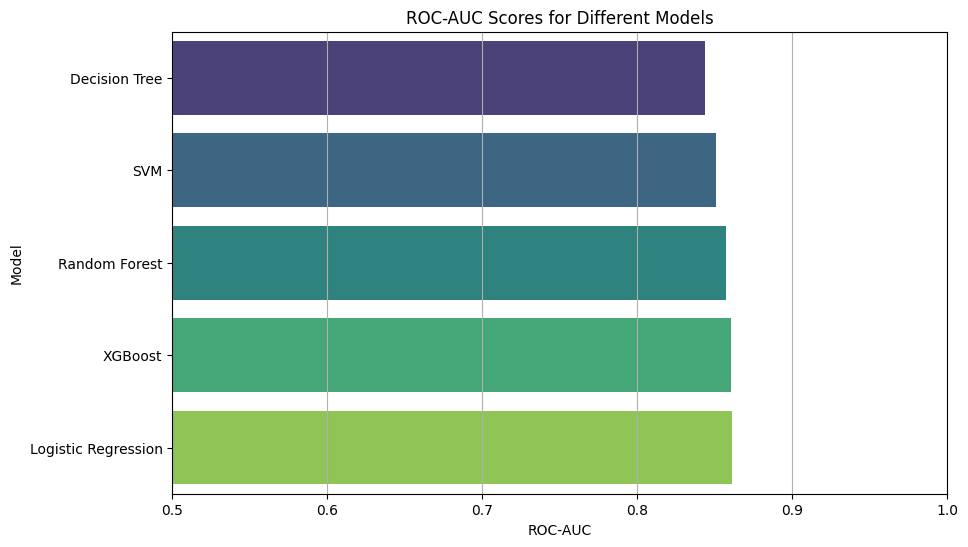

In [ ]:
auc_values = {
    'Decision Tree': auc,
    'Random Forest': auc_rf,
    'Logistic Regression': auc_lr,
    'SVM': auc_svm,
    'XGBoost': auc_xgb
}

auc_df = pd.DataFrame(list(auc_values.items()), columns=['Model', 'ROC-AUC'])
auc_df_sorted = auc_df.sort_values(by='ROC-AUC', ascending=True)


plt.figure(figsize=(10, 6))
sns.barplot(x='ROC-AUC', y='Model', data=auc_df_sorted, palette='viridis')
plt.title('ROC-AUC Scores for Different Models')
plt.xlabel('ROC-AUC')
plt.ylabel('Model')
plt.xlim(0.5, 1.0)
plt.grid(axis='x')
plt.show()

Berdasarkan berbagai model sebelumnya, Logistic Regression memiliki nilai nilai ROC-AUC yang tertinggi sebesar 0.8611. ROC-AUC dipilih karena tidak dipengaruhi oleh distribusi kelas yang tidak seimbang, sedangkan data ini terdapat imbalance antara churn dan no churn. <br>
Accuracy bisa menyesatkan dalam kasus ini karena model bisa mendapatkan skor tinggi hanya dengan memprediksi kelas mayoritas, sedangkan ROC-AUC fokus pada kemampuan model membedakan kedua kelas secara keseluruhan.


### Potensi Dampak performa model berdasarkan ROC-AUC terhadap bisnis

- Model dengan AUC yang lebih tinggi menunjukkan kemampuan yang lebih baik untuk membedakan antara kelas positif dan negatif. Ini mengurangi kesalahan klasifikasi seperti false positives dan false negatives.
- Model dengan AUC yang lebih tinggi menunjukkan generalisasi yang lebih baik, yang meningkatkan kepercayaan pemangku kepentingan terhadap keputusan berbasis data.
- Model dengan AUC tinggi mengurangi kebutuhan untuk intervensi manual atau pengembangan ulang model yang mahal dan memakan waktu.